In [18]:
# define state
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [19]:
#create tool
from langchain_core.tools import tool

@tool
def get_weather(city:str)->str:
    """this functions tells the weather information in a city"""
    return f"the weather in the {city} is sunny"

@tool    
def multiply(a:int,b:int)->str:
    """this function multiplies a and b and returns the value"""
    return str(a*b)


In [20]:
# create LLM
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile")


In [21]:
# bind llm and tools

llm_with_tools = llm.bind_tools([get_weather, multiply])

In [34]:
# create the chatbot node

def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {
        "messages":[response]
    }

In [35]:
# create tool node
# Read tool requests from the LLM
#         ↓
# Execute the tools
#         ↓
# Store tool results in state
from langgraph.prebuilt import ToolNode
tool_node = ToolNode([get_weather,multiply])

In [ ]:
# create Router
from langgraph.constants import END


def route_tools(state : State):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"
    return END

In [44]:

from langgraph.graph import START,END,StateGraph
from langgraph.graph import StateGraph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot",chatbot)
graph_builder.add_node("tools",tool_node)
graph_builder.add_edge(START,"chatbot")
# graph_builder.add_conditional_edges("chatbot",route_tools)
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {
        "tools": "tools",
        "__end__": END
    }
)
graph_builder.add_edge("tools","chatbot")


In [45]:
graph = graph_builder.compile()

In [46]:
from langchain_core.messages import HumanMessage

response = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="what is the weather in hyderabad and what is 4 * 9"
            )
        ]
    }
)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a10d-74e2-99d1-32d6b6008432; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a110-77d1-8705-09bce9cc0651; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a110-77d1-8705-09cc1fc993b0; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a110-77d1-8705-09cc1fc993b0; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a2a4-79b3-9527-4c7f04ec6dc5; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a2a4-79b3-9527-4c7f04ec6dc5; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a110-77d1-8705-09bce9cc0651; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id=019e8d1f-a2a6-7fc2-b7ec-092238fcc954; trace=019e8d1f-a10d-74e2-99d1-32d6b6008432,id

In [47]:

for message in response["messages"]:
    print(message.content)

what is the weather in hyderabad and what is 4 * 9

the weather in the Hyderabad is sunny
36
The weather in Hyderabad is sunny and 4 * 9 = 36.


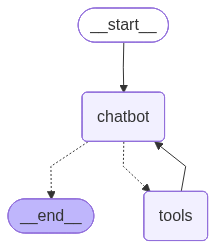

In [48]:
from IPython.display import Image, display

display(
    Image(graph.get_graph().draw_mermaid_png())
)

Added memory to the React agent

In [4]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langchain_groq import ChatGroq


# =====================================
# 1. STATE
# =====================================

class State(TypedDict):
    messages: Annotated[list, add_messages]


# =====================================
# 2. TOOLS
# =====================================

@tool
def get_weather(city: str) -> str:
    """
    Get weather information for a city.
    """
    return f"The weather in {city} is sunny."


@tool
def multiply(a: int, b: int) -> str:
    """
    Multiply two numbers and return the result.
    """
    return str(a * b)


# =====================================
# 3. LLM
# =====================================

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)


# =====================================
# 4. BIND TOOLS TO LLM
# =====================================

llm_with_tools = llm.bind_tools(
    [get_weather, multiply]
)


# =====================================
# 5. CHATBOT NODE
# =====================================

def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


# =====================================
# 6. TOOL NODE
# =====================================

tool_node = ToolNode(
    [get_weather, multiply]
)


# =====================================
# 7. ROUTER
# =====================================

def route_tools(state: State):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END


# =====================================
# 8. CREATE GRAPH
# =====================================

graph_builder = StateGraph(State)


# =====================================
# 9. ADD NODES
# =====================================

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_node(
    "tools",
    tool_node
)


# =====================================
# 10. ADD EDGES
# =====================================

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools
)

graph_builder.add_edge(
    "tools",
    "chatbot"
)

memory = InMemorySaver()
# =====================================
# 11. COMPILE GRAPH
# =====================================

graph = graph_builder.compile(
    checkpointer=memory
)


# =====================================
# 12. INVOKE GRAPH
# =====================================

response = graph.invoke(
    {"messages": [HumanMessage(content="My favorite language is Python")]},
    config={"configurable": {"thread_id": "test"}}
)

response = graph.invoke(
    {"messages": [HumanMessage(content="what is my fevorite language")]},
    config={"configurable": {"thread_id": "test"}}
)



# =====================================
# 13. PRINT RESPONSE
# =====================================

for message in response["messages"]:
    print(message.content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-7fa9-75b2-b706-511a9bbe33b0; trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-7fad-7663-b3a2-63b749ccb0c4; trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-7fae-7fa3-a11b-dfc4c67b0b2f


My favorite language is Python
I'm happy to hear that Python is your favorite language. Is there something specific you'd like to know or discuss about Python, or would you like to explore other topics?
what is my fevorite language
Your favorite language is Python.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-7fae-7fa3-a11b-dfc4c67b0b2f; trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-86c4-7a90-8b2f-d3067a023b91; trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-86c4-7a90-8b2f-d3067a023b91; trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-7fad-7663-b3a2-63b749ccb0c4; trace=019e8e7b-7fa9-75b2-b706-511a9bbe33b0,id=019e8e7b-7fa9-75b2-b706-511a9bbe33b0; trace=019e8e7b-86ca-7102-8fe5-fa0e2884627f,id=019e8e7b-86ca-7102-8fe5-fa0e2884627f; trace=019e8e7b-86ca-7102-8fe5-fa0e2884627f,id=019e8e7b-86ce-76d2-9cb3-b9d1e3aebcd2; trace=019e8e7b-86ca-7102-8fe5-fa0e2884627f,id=019e8e7b-86ce-76d2-9cb3-b9ea39b9fbdb; trace=019e8e7b-86ca-7102-8fe5-fa0e2884627f,id

In [ ]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langchain_groq import ChatGroq


# ====================================
# STATE
# ====================================

class State(TypedDict):
    messages: Annotated[list, add_messages]


# ====================================
# TOOLS
# ====================================

@tool
def get_weather(city: str) -> str:
    """Get weather information for a city."""
    return f"The weather in {city} is sunny."


@tool
def multiply(a: int, b: int) -> str:
    """Multiply two numbers."""
    return str(a * b)


# ====================================
# LLM
# ====================================

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

llm_with_tools = llm.bind_tools(
    [get_weather, multiply]
)


# ====================================
# CHATBOT NODE
# ====================================

def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


# ====================================
# TOOL NODE
# ====================================

tool_node = ToolNode(
    [get_weather, multiply]
)


# ====================================
# ROUTER
# ====================================

def route_tools(state: State):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return END


# ====================================
# GRAPH
# ====================================

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_node(
    "tools",
    tool_node
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools
)

graph_builder.add_edge(
    "tools",
    "chatbot"
)

graph = graph_builder.compile()


# ====================================
# STREAM EXECUTION
# ====================================

for event in graph.stream(
    {
        "messages": [
            HumanMessage(
                content="What is the weather in Hyderabad and what is 4 * 9?"
            )
        ]
    },
    stream_mode="updates"
):

    print("\n====================")
    print(event)


{'chatbot': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vrcpn9t3d', 'function': {'arguments': '{"city":"Hyderabad"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': '4br4hm1m6', 'function': {'arguments': '{"a":4,"b":9}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 278, 'total_tokens': 311, 'completion_time': 0.096356078, 'completion_tokens_details': None, 'prompt_time': 0.027953905, 'prompt_tokens_details': None, 'queue_time': 0.163338265, 'total_time': 0.124309983}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e91cb-c96d-7d12-9154-c43092b2a73d-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Hyderabad'}, 'id': 'vrcpn9t3d', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 4, 'b': 9}, 'id': '4br4hm1m6',

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019e91cb-c950-7232-b148-cf8ae70937dd,id=019e91cb-c950-7232-b148-cf8ae70937dd; trace=019e91cb-c950-7232-b148-cf8ae70937dd,id=019e91cb-c96c-7362-b578-1cc4384ea6af; trace=019e91cb-c950-7232-b148-cf8ae70937dd,id=019e91cb-c96d-7d12-9154-c43092b2a73d
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019e91cb-c950-7232-b148-cf8ae70937dd,id=019e91cb-c96d-7d12-9154-c43092b2a73d; trace=019e91cb-c950-7232-b148-cf8ae70937dd,id=019e91cb-cc69-7f80-a329-7b320d0cc085; trace=019e91cb-

Human in Loop

In [12]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langchain_groq import ChatGroq


# =====================================
# STATE
# =====================================

class State(TypedDict):
    messages: Annotated[list, add_messages]
    approved: bool


# =====================================
# TOOLS
# =====================================

@tool
def get_weather(city: str) -> str:
    """Get weather information."""
    return f"The weather in {city} is sunny."


@tool
def multiply(a: int, b: int) -> str:
    """Multiply two numbers."""
    return str(a * b)


# =====================================
# LLM
# =====================================

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

llm_with_tools = llm.bind_tools(
    [get_weather, multiply]
)


# =====================================
# CHATBOT NODE
# =====================================

def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


# =====================================
# HUMAN APPROVAL NODE
# =====================================

def human_approval(state: State):

    approval = interrupt(
        "Agent wants to execute tools. Approve? (yes/no)"
    )

    return {
        "approved": approval.lower() == "no"
    }


# =====================================
# TOOL NODE
# =====================================

tool_node = ToolNode(
    [get_weather, multiply]
)


# =====================================
# ROUTER 1
# chatbot -> approval / END
# =====================================

def route_tools(state: State):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "approval"

    return END


# =====================================
# ROUTER 2
# approval -> tools / END
# =====================================

def route_approval(state: State):

    if state["approved"]:
        return "tools"

    return END


# =====================================
# BUILD GRAPH
# =====================================

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_node(
    "approval",
    human_approval
)

graph_builder.add_node(
    "tools",
    tool_node
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_conditional_edges(
    "chatbot",
    route_tools
)

graph_builder.add_conditional_edges(
    "approval",
    route_approval
)

graph_builder.add_edge(
    "tools",
    "chatbot"
)


# =====================================
# MEMORY
# =====================================

memory = InMemorySaver()


# =====================================
# COMPILE GRAPH
# =====================================

graph = graph_builder.compile(
    checkpointer=memory
)


# =====================================
# THREAD CONFIG
# =====================================

config = {
    "configurable": {
        "thread_id": "user1"
    }
}


# =====================================
# FIRST RUN
# =====================================

result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="What is the weather in Hyderabad and what is 4 * 9?"
            )
        ]
    },
    config=config
)

print("GRAPH PAUSED")
print(result)


# =====================================
# RESUME GRAPH
# =====================================

result = graph.invoke(
    Command(
        resume="yes"
    ),
    config=config
)

print("\nFINAL RESULT\n")

for msg in result["messages"]:
    print(type(msg).__name__)
    print(msg.content)
    print("-" * 50)

GRAPH PAUSED
{'messages': [HumanMessage(content='What is the weather in Hyderabad and what is 4 * 9?', additional_kwargs={}, response_metadata={}, id='eb2afb22-a62a-4c5a-ada4-0170d4a11161'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y63z8hwtw', 'function': {'arguments': '{"city":"Hyderabad"}', 'name': 'get_weather'}, 'type': 'function'}, {'id': 'vw81kzh13', 'function': {'arguments': '{"a":4,"b":9}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 272, 'total_tokens': 305, 'completion_time': 0.091817655, 'completion_tokens_details': None, 'prompt_time': 0.015828311, 'prompt_tokens_details': None, 'queue_time': 0.050604159, 'total_time': 0.107645966}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e921f-4c00-73f1-963b-10eebdec1611-0', tool_call

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4bf9-7663-8411-b6ab83ce4a97; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4bff-7041-8df8-dcf0053ddd0b; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4c00-73f1-963b-10eebdec1611; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4c00-73f1-963b-10eebdec1611; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4d99-77a2-93f5-a0a11e5ab419; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4d99-77a2-93f5-a0a11e5ab419; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4bff-7041-8df8-dcf0053ddd0b; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id=019e921f-4d9b-71b0-a664-7711623af9a8; trace=019e921f-4bf9-7663-8411-b6ab83ce4a97,id